# Notebook 2: EDA and preprocessing

This notebook first performs **EDA on the untouched cleaned dataset**, and then creates **model-ready datasets** (base / queen / boundary), including reduced variants for sensitivity analysis.

### Inputs
- `datasets/pre-processing/cleaned_crime_nbh_2024.csv`
- `datasets/pre-processing/merged_crime_nbh_2024.gpkg`

### Outputs
- `datasets/model_ready/model_ready_base.csv`
- `datasets/model_ready/model_ready_queen.csv` (+ `.gpkg`)
- `datasets/model_ready/model_ready_boundary.csv` (+ `.gpkg`)
- `datasets/model_ready/model_ready_base_reduced.csv`
- `datasets/model_ready/model_ready_queen_reduced.csv`
- `datasets/model_ready/model_ready_boundary_reduced.csv`

### Audit outputs
- `outputs/pre-processing/missingness_by_column.csv`
- `outputs/pre-processing/preprocessing_audit_summary.csv`


## EDA

### Loading packages and datset

In [29]:
from __future__ import annotations

import logging
import re
from pathlib import Path
from types import SimpleNamespace
from typing import Iterable, Optional

import numpy as np
import pandas as pd
import geopandas as gpd
import pyogrio
import matplotlib.pyplot as plt
import seaborn as sns

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

PREPROC_IN_DIR = Path("datasets/pre-processing")
MODEL_READY_DIR = Path("datasets/model_ready")
MODEL_READY_DIR.mkdir(parents=True, exist_ok=True)

PREPROC_OUT_DIR = Path("outputs/pre-processing")
PREPROC_OUT_DIR.mkdir(parents=True, exist_ok=True)

CFG = SimpleNamespace(
    tabular_csv=PREPROC_IN_DIR / "cleaned_crime_nbh_2024.csv",
    spatial_gpkg=PREPROC_IN_DIR / "merged_crime_nbh_2024.gpkg",
    spatial_layer=None,
    # Always use the cleaned CSV as tabular source; the GeoPackage is used to attach geometry.
    use_merged_gpkg_as_primary=False,
    tabular_key="gwb_code_10",
    spatial_key="gwb_code_10",
    raw_crime_col="GeregistreerdeMisdrijven_1",
    metric_crs="EPSG:28992",
    missing_col_threshold=0.15,
    spillover_candidates=(
        "a_inw",
        "a_woning",
        "a_bedv",
        "a_pau",
        "a_opp_ha",
        "a_ll",
    ),
    export_base_csv=MODEL_READY_DIR / "model_ready_base.csv",
    export_queen_csv=MODEL_READY_DIR / "model_ready_queen.csv",
    export_queen_gpkg=MODEL_READY_DIR / "model_ready_queen.gpkg",
    export_boundary_csv=MODEL_READY_DIR / "model_ready_boundary.csv",
    export_boundary_gpkg=MODEL_READY_DIR / "model_ready_boundary.gpkg",
    export_base_reduced_csv=MODEL_READY_DIR / "model_ready_base_reduced.csv",
    export_queen_reduced_csv=MODEL_READY_DIR / "model_ready_queen_reduced.csv",
    export_boundary_reduced_csv=MODEL_READY_DIR / "model_ready_boundary_reduced.csv",
)


### Untouched-data EDA (cleaned dataset only)

This section runs before any preprocessing or spatial feature engineering.

In [63]:
df_clean = pd.read_csv(CFG.tabular_csv, low_memory=False)
print("cleaned df:", df_clean.shape)

key = CFG.tabular_key
print("\nKey audit:")
print("- missing gwb_code_10:", int(df_clean[key].isna().sum()))
print("- duplicate gwb_code_10:", int(df_clean[key].duplicated().sum()))

num_cols = df_clean.select_dtypes(include=["number"]).columns.tolist()
non_num_cols = [c for c in df_clean.columns if c not in num_cols]
print("\nColumn types:")
print("- numeric:", len(num_cols))
print("- non-numeric:", len(non_num_cols))


cleaned df: (14494, 123)

Key audit:
- missing gwb_code_10: 0
- duplicate gwb_code_10: 0

Column types:
- numeric: 120
- non-numeric: 3


### Target variable inspection

In [64]:
raw_target = CFG.raw_crime_col
if raw_target not in df_clean.columns:
    raise KeyError(f"Missing expected raw target column: {raw_target}")

tgt = pd.to_numeric(df_clean[raw_target], errors="coerce")
print("Raw target describe (GeregistreerdeMisdrijven_1):")
display(tgt.describe())

# EDA-only transform to demonstrate log1p (before preprocessing)
df_clean["crime_count_eda"] = tgt.astype(float)
df_clean["log_crime_count_eda"] = np.log1p(np.clip(df_clean["crime_count_eda"], 0, None))


Raw target describe (GeregistreerdeMisdrijven_1):


count    14494.000000
mean        54.725611
std        121.275987
min          0.000000
25%          8.000000
50%         22.000000
75%         57.000000
max       3714.000000
Name: GeregistreerdeMisdrijven_1, dtype: float64

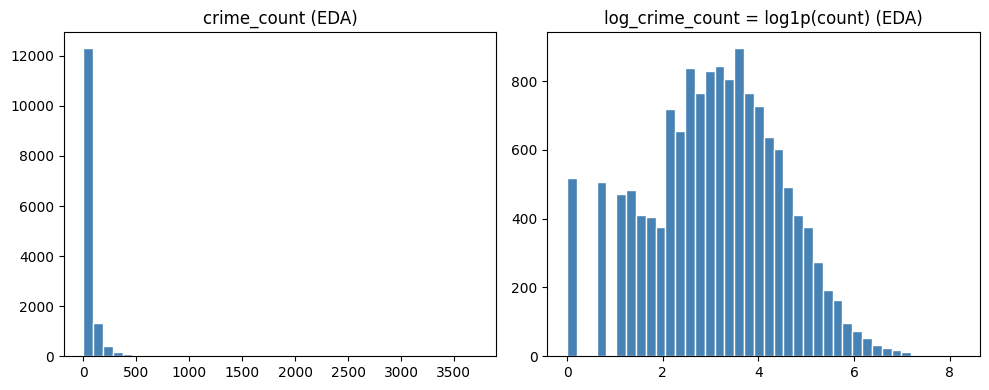

In [65]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(df_clean["crime_count_eda"].clip(lower=0).dropna(), bins=40, color="steelblue", edgecolor="white")
ax[0].set_title("crime_count (EDA)")
ax[1].hist(df_clean["log_crime_count_eda"].dropna(), bins=40, color="steelblue", edgecolor="white")
ax[1].set_title("log_crime_count = log1p(count) (EDA)")
plt.tight_layout()
plt.show()


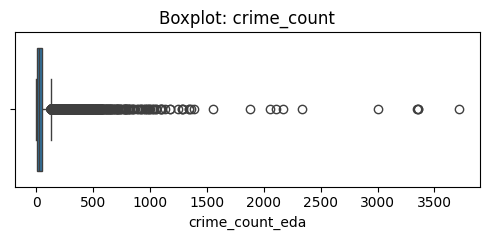

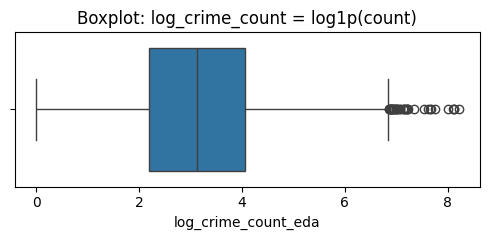

In [71]:
if "crime_count_eda" in df_clean.columns:
    plt.figure(figsize=(5, 2.5))
    sns.boxplot(x=df_clean["crime_count_eda"].clip(lower=0).dropna())
    plt.title("Boxplot: crime_count")
    plt.tight_layout()
    plt.show()

if "log_crime_count_eda" in df_clean.columns:
    plt.figure(figsize=(5, 2.5))
    sns.boxplot(x=df_clean["log_crime_count_eda"].dropna())
    plt.title("Boxplot: log_crime_count = log1p(count)")
    plt.tight_layout()
    plt.show()


### Missing values

In [66]:
# Missingness overview
miss = df_clean.isna().mean().sort_values(ascending=False)
miss_df = pd.DataFrame({"column": miss.index, "pct_missing": (100 * miss.values)})
display(miss_df.head(30))


,column,pct_missing
0,m_hh_ver,100.000000
1,p_arb_zs,100.000000
2,a_lp_pub,100.000000
3,a_wmo_t,100.000000
4,p_wmo_t,100.000000
5,p_jz_tn,100.000000
6,a_jz_tn,100.000000
7,a_opl_bvm,100.000000
8,a_opl_hvm,100.000000
9,a_arb_wz,100.000000


In [67]:
# Missingness buckets

miss_bucket = pd.Series(pd.NA, index=miss.index, dtype="string")

miss_bucket.loc[miss.eq(0)] = "0%"
miss_bucket.loc[miss.gt(0) & miss.le(0.05)] = "0-5%"
miss_bucket.loc[miss.gt(0.05) & miss.le(0.10)] = "5-10%"
miss_bucket.loc[miss.gt(0.10) & miss.le(0.15)] = "10-15%"
miss_bucket.loc[miss.gt(0.15) & miss.le(0.25)] = "15-25%"
miss_bucket.loc[miss.gt(0.25) & miss.le(0.50)] = "25-50%"
miss_bucket.loc[miss.gt(0.50)] = "50-100%"

order = ["0%", "0-5%", "5-10%", "10-15%", "15-25%", "25-50%", "50-100%"]
miss_bucket = pd.Categorical(miss_bucket, categories=order, ordered=True)

print("Missingness buckets (#columns):")
print(pd.Series(miss_bucket).value_counts().sort_index())


Missingness buckets (#columns):
0%         49
0-5%        7
5-10%       9
10-15%     26
15-25%      2
25-50%      4
50-100%    28
Name: count, dtype: int64


### Exploring crime vs population

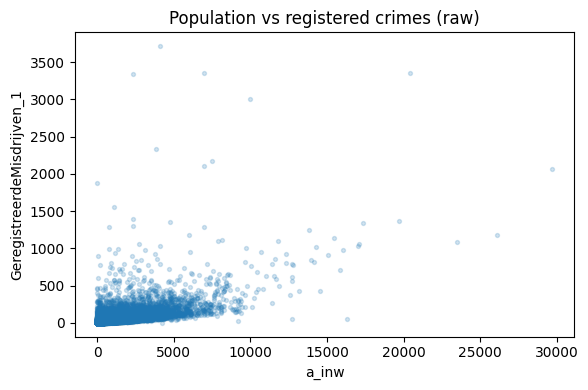

In [70]:
# Population vs crime plot (if available)
if "a_inw" in df_clean.columns:
    x = pd.to_numeric(df_clean["a_inw"], errors="coerce")
    y = pd.to_numeric(df_clean[raw_target], errors="coerce")
    plt.figure(figsize=(6, 4))
    plt.scatter(x, y, alpha=0.2, s=8)  # dots are smaller (s=8)
    plt.xlabel("a_inw")
    plt.ylabel(raw_target)
    plt.title("Population vs registered crimes (raw)")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping population vs crime plot: a_inw not available")


## Preprocessing (model-ready datasets)

This section attaches geometry, creates targets, applies the missingness-threshold filter, and engineers Queen and boundary-weighted spillover features.

**Important**: no imputation is done here; missing values are imputed within-fold in the modeling pipelines.

### Helper functions

In [72]:
# Helper functions
PLACEHOLDER_TOKENS = {".", "", " ", "  "}


def list_gpkg_layers(path: Path):
    layers = pyogrio.list_layers(path)
    return [row[0] for row in layers]


def load_tabular(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(path)
    df = pd.read_csv(
        path,
        low_memory=False,
        dtype={"gwb_code_10": "string", "regio": "string", "gm_naam": "string"},
    )
    logger.info("Loaded tabular: %s rows, %s cols", len(df), df.shape[1])
    return df


def load_spatial(path: Path, layer: Optional[str] = None) -> gpd.GeoDataFrame:
    if not path.exists():
        raise FileNotFoundError(path)
    layer_names = list_gpkg_layers(path)
    if layer is None:
        layer = layer_names[0]
    if layer not in layer_names:
        raise ValueError(f"Layer '{layer}' not found. Available: {layer_names}")

    gdf = gpd.read_file(path, layer=layer, engine="pyogrio")
    logger.info("Loaded spatial layer '%s': %s rows, %s cols", layer, len(gdf), gdf.shape[1])
    return gdf


def standardize_key(s: pd.Series) -> pd.Series:
    return s.astype("string").fillna(pd.NA).str.strip().str.upper()


def audit_duplicates(df: pd.DataFrame, key: str, label: str) -> pd.DataFrame:
    dup = df[key].duplicated(keep=False)
    n_dup = int(dup.sum())
    logger.info("%s duplicate keys in %s: %s", key, label, n_dup)
    if n_dup == 0:
        return pd.DataFrame(columns=[key, "count"])
    out = df.loc[dup, [key]].value_counts().reset_index(name="count")
    return out


def merge_tabular_spatial(df_tab: pd.DataFrame, gdf_spatial: gpd.GeoDataFrame, tab_key: str, spatial_key: str):
    df_tab = df_tab.copy()
    gdf_spatial = gdf_spatial.copy()

    df_tab[tab_key] = standardize_key(df_tab[tab_key])
    gdf_spatial[spatial_key] = standardize_key(gdf_spatial[spatial_key])

    dup_tab = audit_duplicates(df_tab, tab_key, "tabular")
    dup_spa = audit_duplicates(gdf_spatial, spatial_key, "spatial")

    gdf = df_tab.merge(
        gdf_spatial[[spatial_key, "geometry"]],
        how="left",
        left_on=tab_key,
        right_on=spatial_key,
        validate="m:1",
    )
    gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs=gdf_spatial.crs)

    n_total = len(df_tab)
    n_matched = int(gdf["geometry"].notna().sum())
    pct = 100.0 * n_matched / n_total if n_total else 0.0
    logger.info("Merge audit: rows=%s matched=%s pct=%.2f", n_total, n_matched, pct)

    if not dup_tab.empty:
        logger.info("Duplicate keys in tabular: %s", dup_tab.to_dict(orient="records")[:10])
    if not dup_spa.empty:
        logger.info("Duplicate keys in spatial: %s", dup_spa.to_dict(orient="records")[:10])

    return gdf


def clean_placeholders_and_coerce_numeric(df: pd.DataFrame, id_cols: Iterable[str]):
    df = df.copy()
    id_cols = [c for c in id_cols if c in df.columns]

    obj_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
    for c in obj_cols:
        s = df[c].astype("string")
        s = s.str.replace(r"\s+", " ", regex=True)
        s = s.replace(list(PLACEHOLDER_TOKENS), pd.NA)
        df[c] = s

    for c in obj_cols:
        if c in id_cols:
            continue
        s = df[c]
        mask = s.str.match(r"^-?\d{1,3}(?:\.\d{3})*,\d+$", na=False) | s.str.match(r"^-?\d+,\d+$", na=False)
        if mask.any():
            df.loc[mask, c] = s.loc[mask].str.replace(".", "", regex=False).str.replace(",", ".", regex=False)

    for c in df.columns:
        if c in id_cols:
            continue
        if df[c].dtype.name in ("string", "object"):
            s0 = df[c]
            conv = pd.to_numeric(s0, errors="coerce")
            n_in = int(s0.notna().sum())
            n_out = int(conv.notna().sum())
            if n_in > 0 and (n_out / n_in) >= 0.9:
                df[c] = conv

    return df


def create_targets(df: pd.DataFrame, crime_col: str):
    df = df.copy()
    df["crime_count"] = pd.to_numeric(df[crime_col], errors="coerce").astype(float)
    df["log_crime_count"] = np.log1p(np.clip(df["crime_count"], 0, None))
    return df


def drop_high_missing_columns(df: pd.DataFrame, threshold: float, protect_cols: Iterable[str]):
    protect_cols = [c for c in protect_cols if c in df.columns]
    miss = df.isna().mean()
    drop_cols = [c for c in df.columns if (miss[c] > threshold and c not in protect_cols)]
    return df.drop(columns=drop_cols), drop_cols


def ensure_metric_crs(gdf: gpd.GeoDataFrame, metric_crs: str):
    if gdf.crs is None:
        raise ValueError("Spatial data has no CRS; cannot reproject safely")
    if str(gdf.crs).upper() != metric_crs.upper():
        logger.info("Reprojecting from %s to %s", gdf.crs, metric_crs)
        gdf = gdf.to_crs(metric_crs)
    return gdf


def build_queen_neighbors(gdf: gpd.GeoDataFrame, key: str):
    left = gdf[[key, "geometry"]].rename(columns={key: "k"})
    right = gdf[[key, "geometry"]].rename(columns={key: "n"})

    joined = gpd.sjoin(left, right, how="left", predicate="touches")
    joined = joined[joined["n"].notna()]
    joined = joined[joined["k"] != joined["n"]]

    neigh = joined.groupby("k")["n"].apply(list)
    neigh = neigh.reindex(gdf[key]).apply(lambda x: x if isinstance(x, list) else [])

    degrees = neigh.apply(len)
    summary = pd.DataFrame(
        {
            "n_units": [len(gdf)],
            "avg_neighbors": [degrees.mean()],
            "min_neighbors": [degrees.min()],
            "max_neighbors": [degrees.max()],
            "pct_islands": [100.0 * (degrees.eq(0).mean())],
        }
    )
    return neigh, summary


def add_spillover_lags(df: pd.DataFrame, key: str, neighbors: pd.Series, features: list[str], prefix: str = "queen", islands_fill=np.nan):
    df = df.copy().set_index(key, drop=False)

    for feat in features:
        vals = pd.to_numeric(df[feat], errors="coerce")
        lag_sum = []
        lag_mean = []
        for k, neigh_list in neighbors.items():
            if not neigh_list:
                lag_sum.append(islands_fill)
                lag_mean.append(islands_fill)
                continue
            neigh_vals = vals.reindex(neigh_list)
            lag_sum.append(neigh_vals.sum(skipna=True, min_count=1))
            lag_mean.append(neigh_vals.mean(skipna=True))
        df[f"{prefix}_lag_sum_{feat}"] = lag_sum
        df[f"{prefix}_lag_mean_{feat}"] = lag_mean

    return df.reset_index(drop=True)


### Loading cleaned set

In [38]:
# Load cleaned tabular and merged spatial artifacts

df_raw = load_tabular(CFG.tabular_csv)
gdf_spatial_raw = load_spatial(CFG.spatial_gpkg, layer=CFG.spatial_layer)

# Standardize/verify keys and attach geometry

df_tab = df_raw.copy()
df_tab[CFG.tabular_key] = standardize_key(df_tab[CFG.tabular_key])

gdf_spatial = gdf_spatial_raw.copy()
if CFG.spatial_key in gdf_spatial.columns:
    gdf_spatial[CFG.spatial_key] = standardize_key(gdf_spatial[CFG.spatial_key])

# Always use the cleaned CSV as the primary tabular source.
# The GeoPackage is used to attach geometry (and avoids bypassing cleaning decisions).
print("Primary source for preprocessing (tabular):", str(CFG.tabular_csv))
print("Geometry source (gpkg):", str(CFG.spatial_gpkg))

gdf_merged = merge_tabular_spatial(df_tab, gdf_spatial, CFG.tabular_key, CFG.spatial_key)

print("Merged gdf:", gdf_merged.shape)
print("Missing geometry rows:", int(gdf_merged.geometry.isna().sum()))


INFO: Loaded tabular: 14494 rows, 123 cols
INFO: Loaded spatial layer 'merged_crime_nbh_2024': 14494 rows, 134 cols
INFO: gwb_code_10 duplicate keys in tabular: 0
INFO: gwb_code_10 duplicate keys in spatial: 0
INFO: Merge audit: rows=14494 matched=14494 pct=100.00


Primary source for preprocessing (tabular): datasets/pre-processing/cleaned_crime_nbh_2024.csv
Geometry source (gpkg): datasets/pre-processing/merged_crime_nbh_2024.gpkg
Merged gdf: (14494, 124)
Missing geometry rows: 0


### Create total education column

In [ ]:
# Clean placeholders / numerics
IDENTIFIER_COLS = [CFG.tabular_key, "regio", "gm_naam"]
SPATIAL_META_COLS = [c for c in ["centroid_x", "centroid_y"] if c in gdf_merged.columns]

gdf_clean = clean_placeholders_and_coerce_numeric(gdf_merged, id_cols=IDENTIFIER_COLS)

# Targets + engineered education aggregate

gdf_targets = create_targets(gdf_clean, crime_col=CFG.raw_crime_col)

edu_cols = ["a_ons_po", "a_ons_vovavo", "a_ons_mbo", "a_ons_hbo", "a_ons_wo"]
for c in edu_cols:
    if c not in gdf_targets.columns:
        raise KeyError(f"Missing required column for a_ll: {c}")

gdf_targets["a_ll"] = (
    gdf_targets[edu_cols]
    .apply(pd.to_numeric, errors="coerce")
    .sum(axis=1, min_count=1)
)

print("Rows after target creation:", len(gdf_targets))


Rows after target creation: 14494


### Dropping >15% missingness columns

In [40]:
# Apply missingness-threshold dropping (protect identifiers + targets)
model_gdf = gdf_targets.copy()
TARGET_COLS = ["log_crime_count"]
NON_FEATURE_COLS = ["crime_count"]
PROTECT_COLS = IDENTIFIER_COLS + SPATIAL_META_COLS + TARGET_COLS + NON_FEATURE_COLS

filtered_gdf, dropped_cols = drop_high_missing_columns(model_gdf, CFG.missing_col_threshold, protect_cols=PROTECT_COLS)
print(f"Dropped {len(dropped_cols)} columns with missingness > {CFG.missing_col_threshold:.0%}")


Dropped 34 columns with missingness > 15%


### Spatial weights and spillover feature engineering

In [41]:
# Spatial weights and spillover feature engineering
geo_ready = filtered_gdf.dropna(subset=["geometry"]).copy()
geo_ready = ensure_metric_crs(geo_ready, CFG.metric_crs)

neighbors, w_summary = build_queen_neighbors(geo_ready, key=CFG.tabular_key)
print("Queen neighbor summary:")
display(w_summary)

available = set(geo_ready.columns)
spillover_features = [c for c in CFG.spillover_candidates if c in available]
missing_spill = [c for c in CFG.spillover_candidates if c not in available]
if missing_spill:
    raise ValueError(f"Missing required spillover predictors in dataset: {missing_spill}")

spatial_gdf = add_spillover_lags(
    df=geo_ready,
    key=CFG.tabular_key,
    neighbors=neighbors,
    features=spillover_features,
    prefix="queen",
    islands_fill=np.nan,
)

TARGET_LAG_LIKE = [
    c
    for c in spatial_gdf.columns
    if re.search(r"lag_.*crime|crime.*lag|spillover_lag", c, flags=re.IGNORECASE)
]


Queen neighbor summary:


,n_units,avg_neighbors,min_neighbors,max_neighbors,pct_islands
0,14494,5.731199,0,36,0.068994


In [44]:
# Prepare base + queen datasets
base_dataset = filtered_gdf.copy()
base_dataset = pd.DataFrame(base_dataset.drop(columns=["geometry"], errors="ignore"))

queen_dataset = spatial_gdf.copy()

# Leakage protection: ensure no contemporaneous target lags are exported
if TARGET_LAG_LIKE:
    base_dataset = base_dataset.drop(columns=[c for c in TARGET_LAG_LIKE if c in base_dataset.columns], errors="ignore")
    queen_dataset = queen_dataset.drop(columns=[c for c in TARGET_LAG_LIKE if c in queen_dataset.columns], errors="ignore")

queen_dataset = queen_dataset.set_geometry("geometry")


In [ ]:
# Boundary-length weighted spillovers (row-standardised)
boundary_vars = list(CFG.spillover_candidates)

spatial_for_boundary = geo_ready.copy()
geom_by_key = spatial_for_boundary.set_index(CFG.tabular_key)["geometry"]

corner_only_excluded = {}
row_denoms = {}
all_weights = []
weight_sum_violations = []

for key_i, neighs in neighbors.items():
    gi = geom_by_key.get(key_i)
    if gi is None or neighs is None:
        corner_only_excluded[key_i] = 0
        row_denoms[key_i] = 0.0
        continue

    lengths = []
    zero_ct = 0
    for key_j in neighs:
        gj = geom_by_key.get(key_j)
        if gj is None:
            continue
        lij = gi.boundary.intersection(gj.boundary).length
        if lij <= 0:
            zero_ct += 1
            continue
        lengths.append(float(lij))

    corner_only_excluded[key_i] = int(zero_ct)
    denom = float(sum(lengths))
    row_denoms[key_i] = denom

    if denom > 0:
        w_sum = 0.0
        for lij in lengths:
            w = lij / denom
            w_sum += w
            all_weights.append(w)
        if not np.isclose(w_sum, 1.0, atol=1e-8):
            weight_sum_violations.append((key_i, w_sum))

boundary_lags = pd.DataFrame({CFG.tabular_key: list(geom_by_key.index)})

for var in boundary_vars:
    x = pd.to_numeric(spatial_for_boundary.set_index(CFG.tabular_key)[var], errors="coerce")

    vals = []
    for key_i in geom_by_key.index:
        neighs = neighbors.get(key_i, [])
        if not neighs:
            vals.append(np.nan)
            continue

        gi = geom_by_key.get(key_i)
        if gi is None:
            vals.append(np.nan)
            continue

        num = 0.0
        denom = 0.0
        for key_j in neighs:
            xj = x.get(key_j)
            if pd.isna(xj):
                continue
            gj = geom_by_key.get(key_j)
            if gj is None:
                continue
            lij = gi.boundary.intersection(gj.boundary).length
            if lij <= 0:
                continue
            lij = float(lij)
            num += lij * float(xj)
            denom += lij

        vals.append(np.nan if denom <= 0 else (num / denom))

    boundary_lags[f"boundary_lag_{var}"] = vals

boundary_islands = sum(1 for k in geom_by_key.index if row_denoms.get(k, 0.0) <= 0.0)

boundary_gdf = ensure_metric_crs(filtered_gdf.copy(), CFG.metric_crs)
boundary_gdf = boundary_gdf.merge(boundary_lags, on=CFG.tabular_key, how="left")
boundary_csv = pd.DataFrame(boundary_gdf.drop(columns=["geometry"], errors="ignore"))

print("Boundary islands:", int(boundary_islands))


### Creating reduced datasets for sensitivity analysis

Reduced datasets drop **non-spatial predictor columns** that contain any missing values.

`queen_lag_*` and `boundary_lag_*` features may still contain `NaN` values for **islands** (neighbourhoods with no neighbours). This is intentional: these missing lag values are imputed **within-fold** inside the sklearn pipelines during modeling, which preserves leakage safety.

In [ ]:
# Reduced datasets (sensitivity analysis)
missing_rate = model_gdf.isna().mean().sort_values(ascending=False)
high_missing = missing_rate[missing_rate > CFG.missing_col_threshold]
retained_despite_missingness = [c for c in high_missing.index if c in PROTECT_COLS]

removed_spillover_sources = [c for c in retained_despite_missingness if c in set(spillover_features)]
queen_lag_cols_to_drop = []
for v in removed_spillover_sources:
    queen_lag_cols_to_drop.extend([f"queen_lag_sum_{v}", f"queen_lag_mean_{v}"])

boundary_lag_cols_to_drop = [f"boundary_lag_{v}" for v in removed_spillover_sources]

id_set = set(IDENTIFIER_COLS + SPATIAL_META_COLS + TARGET_COLS + NON_FEATURE_COLS)

def _drop_any_missing_predictors(df: pd.DataFrame, *, allow_missing_prefixes: tuple[str, ...] = ()) -> tuple[pd.DataFrame, list[str]]:
    df = df.copy()
    pred_cols = [c for c in df.columns if c not in id_set]

    def _is_allowed(c: str) -> bool:
        return any(c.startswith(p) for p in allow_missing_prefixes)

    cols_with_any_missing = [c for c in pred_cols if (not _is_allowed(c)) and df[c].isna().any()]
    return df.drop(columns=cols_with_any_missing, errors="ignore"), cols_with_any_missing

base_reduced = base_dataset.drop(columns=[c for c in retained_despite_missingness if c in base_dataset.columns], errors="ignore")
base_reduced, _ = _drop_any_missing_predictors(base_reduced, allow_missing_prefixes=("queen_lag_", "boundary_lag_"))

queen_reduced_csv = pd.DataFrame(queen_dataset.drop(columns=["geometry"], errors="ignore"))
queen_reduced_csv = queen_reduced_csv.drop(columns=[c for c in (retained_despite_missingness + queen_lag_cols_to_drop) if c in queen_reduced_csv.columns], errors="ignore")
queen_reduced_csv, _ = _drop_any_missing_predictors(queen_reduced_csv, allow_missing_prefixes=("queen_lag_", "boundary_lag_"))

boundary_reduced_csv = boundary_csv.drop(columns=[c for c in (retained_despite_missingness + boundary_lag_cols_to_drop) if c in boundary_csv.columns], errors="ignore")
boundary_reduced_csv, _ = _drop_any_missing_predictors(boundary_reduced_csv, allow_missing_prefixes=("queen_lag_", "boundary_lag_"))

# Print remaining NaNs in lag columns (islands) for reduced queen/boundary datasets
queen_lag_cols = [c for c in queen_reduced_csv.columns if c.startswith("queen_lag_")]
boundary_lag_cols_q = [c for c in queen_reduced_csv.columns if c.startswith("boundary_lag_")]

boundary_lag_cols = [c for c in boundary_reduced_csv.columns if c.startswith("boundary_lag_")]
queen_lag_cols_b = [c for c in boundary_reduced_csv.columns if c.startswith("queen_lag_")]

print("\nRemaining missing values in reduced lag columns (islands):")
print("- queen reduced: queen_lag_* NaNs:", int(queen_reduced_csv[queen_lag_cols].isna().sum().sum()) if queen_lag_cols else 0)
print("- queen reduced: boundary_lag_* NaNs:", int(queen_reduced_csv[boundary_lag_cols_q].isna().sum().sum()) if boundary_lag_cols_q else 0)
print("- boundary reduced: boundary_lag_* NaNs:", int(boundary_reduced_csv[boundary_lag_cols].isna().sum().sum()) if boundary_lag_cols else 0)
print("- boundary reduced: queen_lag_* NaNs:", int(boundary_reduced_csv[queen_lag_cols_b].isna().sum().sum()) if queen_lag_cols_b else 0)



Remaining missing values in reduced lag columns (islands):
- queen reduced: queen_lag_* NaNs: 120
- queen reduced: boundary_lag_* NaNs: 0
- boundary reduced: boundary_lag_* NaNs: 60
- boundary reduced: queen_lag_* NaNs: 0


## 3. Post-preprocessing checks (model-ready)

Quick sanity checks after target creation and spillover feature engineering (before export).

### Defining predictor and target variables

In [46]:
# Predictor counts using the same logic as modeling (numeric-only + exclusions)
RAW_TARGET_LIKE = {"crime_count", CFG.raw_crime_col}
LEAKAGE_PATTERNS = [
    r"spillover_spec",
    r"spillover_target",
    r"target_lag",
    r"lag_y",
    r"spillover_lag",
    r"lag_.*crime",
    r"crime.*lag",
]
LEAKAGE_REGEX = re.compile("|".join(LEAKAGE_PATTERNS), flags=re.IGNORECASE)

ID_COLS_BASE = [
    "gwb_code_10",
    "gwb_code_8",
    "gwb_code",
    "ind_wbi",
    "merge_key",
    "regio",
    "gm_naam",
    "ID",
    "Perioden",
    "SoortMisdrijf",
    "recs",
    "centroid_x",
    "centroid_y",
]


def _selected_numeric_predictor_cols(df: pd.DataFrame, *, target: str, id_cols: list[str]) -> list[str]:
    # Leakage patterns are kept only as a warning signal (defense-in-depth).
    leak = [c for c in df.columns if LEAKAGE_REGEX.search(c)]
    if leak:
        print("WARNING: columns matching leakage patterns were found:")
        print(leak)

    # For this post-preprocessing audit we count selected numeric predictors based on explicit exclusions only.
    exclude = set([c for c in id_cols if c in df.columns]) | set([c for c in RAW_TARGET_LIKE if c in df.columns]) | {target}
    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    return [c for c in num_cols if c not in exclude]


target = "log_crime_count"
queen_full_csv = pd.DataFrame(queen_dataset.drop(columns=["geometry"], errors="ignore"))

base_feats = _selected_numeric_predictor_cols(base_dataset, target=target, id_cols=ID_COLS_BASE)
queen_feats = _selected_numeric_predictor_cols(queen_full_csv, target=target, id_cols=ID_COLS_BASE)
boundary_feats = _selected_numeric_predictor_cols(boundary_csv, target=target, id_cols=ID_COLS_BASE)

print("Selected numeric predictor counts:")
print("- base:", len(base_feats))
print("- queen:", len(queen_feats))
print("- boundary:", len(boundary_feats))


Selected numeric predictor counts:
- base: 86
- queen: 98
- boundary: 92


### Missingness check

In [ ]:
# Missingness after preprocessing
miss_post = base_dataset.isna().mean().sort_values(ascending=False)
print("Top missingness (base dataset):")
display(pd.DataFrame({"missing_rate": miss_post}).head(15))


Top missingness (base dataset):


,missing_rate
a_bed_gi,0.125983
a_bed_ru,0.125983
a_bed_a,0.125983
a_bed_bf,0.125983
a_bed_hj,0.125983
a_bed_kl,0.125983
a_bed_mn,0.125983
a_bed_oq,0.125983
g_wozbag,0.124948
p_ov_hw,0.114323


### Exploring predictors

In [48]:
# Skewness of selected predictors (base)
base_num = pd.DataFrame(base_dataset[base_feats]).apply(pd.to_numeric, errors="coerce")
skew = base_num.skew(numeric_only=True).sort_values(ascending=False)
print("Top skewed predictors (base):")
display(skew.head(15))


Top skewed predictors (base):


a_wat_ha      22.129925
a_bst_nb      19.498745
a_nb_vastg    19.076254
a_nb_won      12.594555
a_ons_wo      11.917558
a_bed_bf      10.392372
p_ste          9.430822
a_geb_ne       8.362571
a_bed_a        8.303289
a_neu_al       8.097783
a_gbl_ne       7.861051
a_soz_wb       7.710605
a_gbl_eu       7.593395
a_bed_kl       7.380137
a_lan_ha       6.705447
dtype: float64

### Exploring correlation with target

In [49]:
# Correlation with target (base)
y = pd.to_numeric(base_dataset[target], errors="coerce")
corr = base_num.corrwith(y).sort_values(key=lambda s: s.abs(), ascending=False)
print("Top correlations with log_crime_count (base):")
display(corr.head(15))


Top correlations with log_crime_count (base):


a_hh        0.664969
a_woning    0.664121
a_bedv      0.657819
a_soz_ww    0.648184
a_man       0.647196
a_inw       0.646208
a_ongeh     0.645597
a_vrouw     0.643967
a_25_44     0.642167
a_bed_oq    0.640245
a_hh_z_k    0.638278
a_1p_hh     0.631405
a_gesch     0.628403
a_bed_ru    0.627679
ste_mvs    -0.620733
dtype: float64

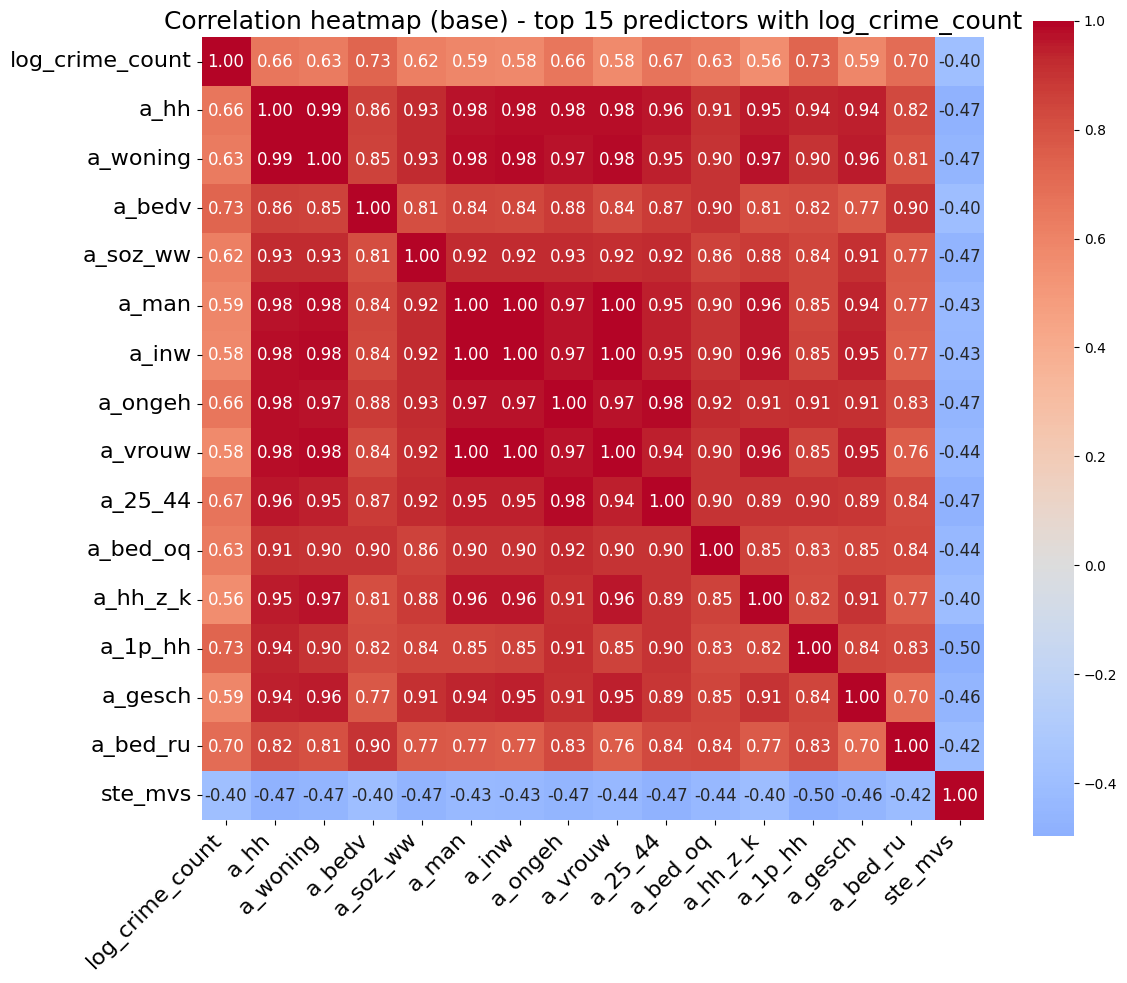

In [75]:
# Correlation heatmap (base, top 15 by |corr|), including target variable

top15 = corr.dropna().abs().sort_values(ascending=False).head(15).index.tolist()

top15 = [col for col in top15 if col != target]

cols_for_heatmap = [target] + top15

if target in base_num.columns:
    corr_matrix = base_num[cols_for_heatmap].corr()
else:
    corr_matrix = base_num[top15].assign(**{target: y})[cols_for_heatmap].corr()

plt.figure(figsize=(12, 10))

ax = sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    cbar=True,
    annot_kws={"size": 12},
    square=True,
    xticklabels=[col for col in cols_for_heatmap],
    yticklabels=[col for col in cols_for_heatmap]
)

# Increase font size of variable names (axis tick labels)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=16, rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), fontsize=16, rotation=0)

plt.title(f"Correlation heatmap (base) - top 15 predictors with {target}", fontsize=18)
plt.tight_layout()
plt.show()

### Spatial lag summary

In [60]:
print("Spatial lag summary:")
display(w_summary)
print("Boundary islands:", int(boundary_islands))


Spatial lag summary:


,n_units,avg_neighbors,min_neighbors,max_neighbors,pct_islands
0,14494,5.731199,0,36,0.068994


Boundary islands: 10


### Save new datasets

In [61]:
# Exports (full)
CFG.export_base_csv.parent.mkdir(parents=True, exist_ok=True)
base_dataset.to_csv(CFG.export_base_csv, index=False)

CFG.export_queen_gpkg.parent.mkdir(parents=True, exist_ok=True)
# GeoPackage export kept for downstream spatial analysis/visualisation (model training uses the CSV exports).
queen_dataset.to_file(CFG.export_queen_gpkg, layer="model_ready_queen", driver="GPKG")
CFG.export_queen_csv.parent.mkdir(parents=True, exist_ok=True)
pd.DataFrame(queen_dataset.drop(columns=["geometry"], errors="ignore")).to_csv(CFG.export_queen_csv, index=False)

CFG.export_boundary_csv.parent.mkdir(parents=True, exist_ok=True)
boundary_csv.to_csv(CFG.export_boundary_csv, index=False)
CFG.export_boundary_gpkg.parent.mkdir(parents=True, exist_ok=True)
# GeoPackage export kept for downstream spatial analysis/visualisation (model training uses the CSV exports).
boundary_gdf.to_file(CFG.export_boundary_gpkg, layer="model_ready_boundary", driver="GPKG")

# Exports (reduced)
CFG.export_base_reduced_csv.parent.mkdir(parents=True, exist_ok=True)
base_reduced.to_csv(CFG.export_base_reduced_csv, index=False)
CFG.export_queen_reduced_csv.parent.mkdir(parents=True, exist_ok=True)
queen_reduced_csv.to_csv(CFG.export_queen_reduced_csv, index=False)
CFG.export_boundary_reduced_csv.parent.mkdir(parents=True, exist_ok=True)
boundary_reduced_csv.to_csv(CFG.export_boundary_reduced_csv, index=False)

print("\nSaved model-ready datasets under:", MODEL_READY_DIR)


INFO: Created 14,494 records
INFO: Created 14,494 records



Saved model-ready datasets under: datasets/model_ready


### Pre-processing audit

In [62]:
# Audit outputs (preprocessing)

# Missingness overview after preprocessing (full base)
miss_after = base_dataset.isna().mean().sort_values(ascending=False)
miss_only = miss_after[miss_after > 0].reset_index()
miss_only.columns = ["column", "missing_rate"]
miss_path = PREPROC_OUT_DIR / "missingness_by_column.csv"
miss_path.parent.mkdir(parents=True, exist_ok=True)
miss_only.to_csv(miss_path, index=False)

# Preprocessing audit summary
preproc_audit = {
    "starting_row_count": int(len(df_raw)),
    "final_row_count": int(len(model_gdf)),
    "starting_column_count": int(df_raw.shape[1]),
    "final_base_columns": int(base_dataset.shape[1]),
    "final_queen_columns": int(pd.DataFrame(queen_dataset.drop(columns=["geometry"], errors="ignore")).shape[1]),
    "final_boundary_columns": int(boundary_csv.shape[1]),
    "n_columns_dropped_missingness": int(len(dropped_cols)),
    "selected_spillover_variables": spillover_features,
    "avg_neighbors": float(w_summary["avg_neighbors"].iloc[0]),
    "min_neighbors": int(w_summary["min_neighbors"].iloc[0]),
    "max_neighbors": int(w_summary["max_neighbors"].iloc[0]),
    "pct_islands": float(w_summary["pct_islands"].iloc[0]),
    "boundary_islands": int(boundary_islands),
}

audit_df = pd.DataFrame([preproc_audit])
audit_out = PREPROC_OUT_DIR / "preprocessing_audit_summary.csv"
audit_out.parent.mkdir(parents=True, exist_ok=True)
audit_df.to_csv(audit_out, index=False)

print("Saved audit outputs:")
print("-", miss_path)
print("-", audit_out)


Saved audit outputs:
- outputs/pre-processing/missingness_by_column.csv
- outputs/pre-processing/preprocessing_audit_summary.csv


In [84]:
# Import the datasets and print the total features for each

MODEL_READY_DIR = "datasets/model_ready"
base_dataset = pd.read_csv(f"{MODEL_READY_DIR}/model_ready_base.csv")
base_dataset_reduced = pd.read_csv(f"{MODEL_READY_DIR}/model_ready_base_reduced.csv")

print(f"Total columns in full base set: {base_dataset.shape[1]}")
print(f"Total columns in reduced base set: {base_dataset_reduced.shape[1]}")

Total columns in full base set: 92
Total columns in reduced base set: 50


In [85]:
# ID and leakage exclusion rules as in modeling
ID_COLS_BASE = [
    "gwb_code_10",
    "gwb_code_8",
    "gwb_code",
    "ind_wbi",
    "merge_key",
    "regio",
    "gm_naam",
    "ID",
    "Perioden",
    "SoortMisdrijf",
    "recs",
    "centroid_x",
    "centroid_y",
]
RAW_TARGET_LIKE = {
    "crime_count",
    "crime_rate_per_1000",
    "GeregistreerdeMisdrijven_1",
}
LEAKAGE_PATTERNS = [
    r"spillover_spec",
    r"spillover_target",
    r"target_lag",
    r"lag_y",
    r"spillover_lag",
    r"lag_.*crime",
    r"crime.*lag",
]
LEAKAGE_REGEX = re.compile("|".join(LEAKAGE_PATTERNS), flags=re.IGNORECASE)
TARGET_COL = "log_crime_count"  # Fixed project target

def n_modeling_predictors(df, id_cols, target, raw_target_like, leakage_regex):
    # Exclude columns as in modeling pipeline
    leak = [c for c in df.columns if leakage_regex.search(c)]
    exclude = set([c for c in id_cols if c in df.columns]) \
              | set(leak) \
              | set([c for c in raw_target_like if c in df.columns]) \
              | {target}
    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    feature_cols = [c for c in num_cols if c not in exclude]
    return len(feature_cols)

print(f"Predictor features in full base set: {n_modeling_predictors(base_dataset, ID_COLS_BASE, TARGET_COL, RAW_TARGET_LIKE, LEAKAGE_REGEX)}")
print(f"Predictor features in reduced base set: {n_modeling_predictors(base_dataset_reduced, ID_COLS_BASE, TARGET_COL, RAW_TARGET_LIKE, LEAKAGE_REGEX)}")

Predictor features in full base set: 86
Predictor features in reduced base set: 44


## Outputs saved

### Model-ready datasets (written to `datasets/model_ready/`)
- `datasets/model_ready/model_ready_base.csv`
- `datasets/model_ready/model_ready_queen.csv` and `datasets/model_ready/model_ready_queen.gpkg`
- `datasets/model_ready/model_ready_boundary.csv` and `datasets/model_ready/model_ready_boundary.gpkg`
- `datasets/model_ready/model_ready_base_reduced.csv`
- `datasets/model_ready/model_ready_queen_reduced.csv`
- `datasets/model_ready/model_ready_boundary_reduced.csv`

### Audit outputs (written to `outputs/pre-processing/`)
- `outputs/pre-processing/missingness_by_column.csv`
- `outputs/pre-processing/preprocessing_audit_summary.csv`
